# SHAP Analysis - Retail Demand Forecasting

This notebook performs SHAP (SHapley Additive exPlanations) analysis on the trained XGBoost model to understand feature contributions and model interpretability.

In [2]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
shap.initjs()
print("All imports successful")

c:\Users\sanja\Documents\GitHub\retail-demand-forecasting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful


In [3]:
# Cell 2 — Load clean data + rebuild features
df = pd.read_csv('../data/processed/walmart_clean.csv', parse_dates=['Date'])

def build_features(df):
    df = df.copy()
    df = df.sort_values(['Store','Dept','Date'])

    df['Week']        = df['Date'].dt.isocalendar().week.astype(int)
    df['Month']       = df['Date'].dt.month
    df['Quarter']     = df['Date'].dt.quarter
    df['Year']        = df['Date'].dt.year
    df['IsHoliday']   = df['IsHoliday'].astype(int)

    grp = df.groupby(['Store','Dept'])['Weekly_Sales']
    df['lag_1']       = grp.shift(1)
    df['lag_4']       = grp.shift(4)
    df['lag_8']       = grp.shift(8)
    df['lag_52']      = grp.shift(52)

    df['rolling_mean_4']  = grp.shift(1).transform(lambda x: x.rolling(4,  min_periods=1).mean())
    df['rolling_mean_12'] = grp.shift(1).transform(lambda x: x.rolling(12, min_periods=1).mean())
    df['rolling_std_4']   = grp.shift(1).transform(lambda x: x.rolling(4,  min_periods=1).std().fillna(0))

    df['MarkDown_Total'] = (
        df['MarkDown1'] + df['MarkDown2'] +
        df['MarkDown3'] + df['MarkDown4'] + df['MarkDown5']
    )

    le = LabelEncoder()
    df['Type_enc'] = le.fit_transform(df['Type'])

    return df

df_feat = build_features(df)
df_feat = df_feat.dropna(subset=['lag_1','lag_4']).reset_index(drop=True)

print(f"Feature dataset shape: {df_feat.shape}")

Feature dataset shape: (407188, 29)


In [4]:
# Cell 3 — Load trained XGBoost model
FEATURES = [
    'Store','Dept','Week','Month','Quarter','Year',
    'IsHoliday','Type_enc','Size',
    'Temperature','Fuel_Price','CPI','Unemployment',
    'MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5','MarkDown_Total',
    'lag_1','lag_4','lag_8','lag_52',
    'rolling_mean_4','rolling_mean_12','rolling_std_4'
]

xgb_model = XGBRegressor()
xgb_model.load_model('../data/processed/xgb_model.json')

print("XGBoost model loaded successfully")

XGBoost model loaded successfully


In [5]:
# Cell 4 — Compute SHAP values
# Use a sample of 2000 rows for speed
sample_df = df_feat.sample(n=2000, random_state=42)
X_sample  = sample_df[FEATURES]

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP computation complete")

SHAP values shape: (2000, 26)
SHAP computation complete


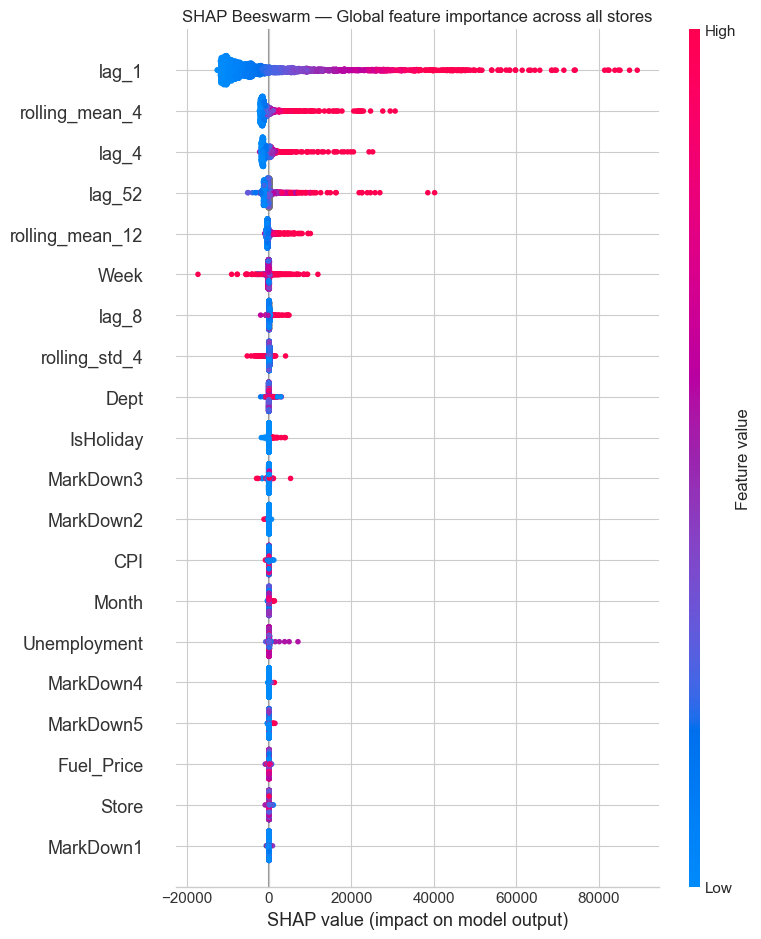

Beeswarm plot saved → docs/shap_beeswarm.png


In [6]:
# Cell 5 — Global feature importance (beeswarm plot)
plt.figure(figsize=(10,8))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=FEATURES,
    plot_type='dot',
    show=False
)
plt.title('SHAP Beeswarm — Global feature importance across all stores')
plt.tight_layout()
plt.savefig('../docs/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Beeswarm plot saved → docs/shap_beeswarm.png")

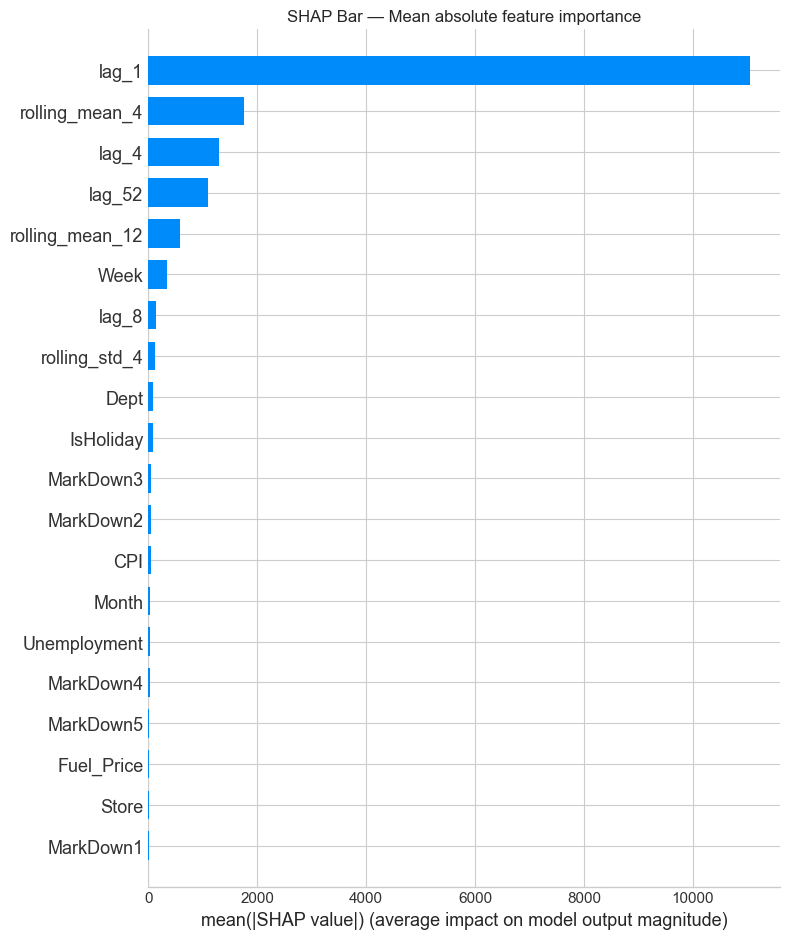

Bar plot saved → docs/shap_bar.png


In [7]:
# Cell 6 — Global bar plot
plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=FEATURES,
    plot_type='bar',
    show=False
)
plt.title('SHAP Bar — Mean absolute feature importance')
plt.tight_layout()
plt.savefig('../docs/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Bar plot saved → docs/shap_bar.png")

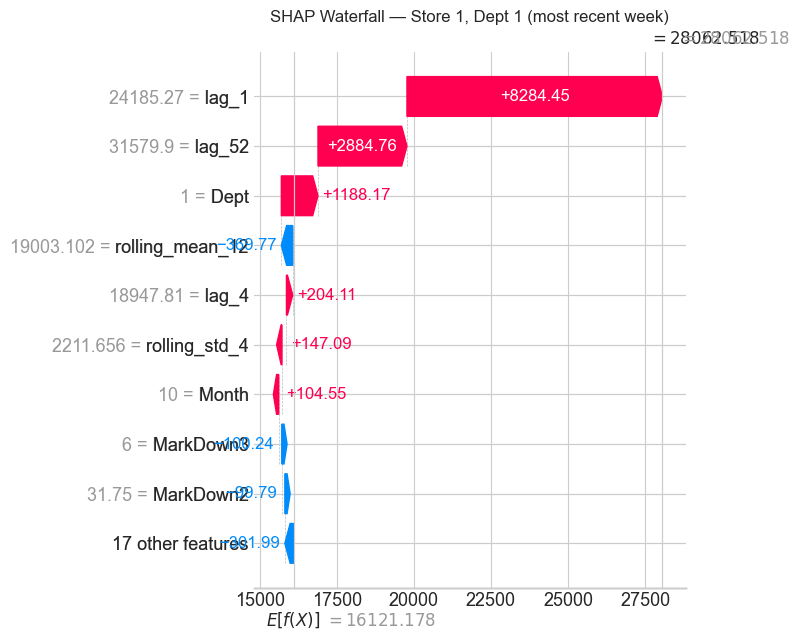

Waterfall plot saved → docs/shap_waterfall_store1.png


In [8]:
# Cell 7 — Waterfall plot for single prediction (Store 1, Dept 1)
# Get a single row — Store 1, Dept 1, most recent date
single_row = (
    df_feat[(df_feat['Store'] == 1) & (df_feat['Dept'] == 1)]
    .sort_values('Date')
    .tail(1)
)

X_single     = single_row[FEATURES]
shap_single  = explainer(X_single)

plt.figure(figsize=(12,6))
shap.plots.waterfall(shap_single[0], show=False)
plt.title('SHAP Waterfall — Store 1, Dept 1 (most recent week)')
plt.tight_layout()
plt.savefig('../docs/shap_waterfall_store1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Waterfall plot saved → docs/shap_waterfall_store1.png")

SHAP — Holiday feature impact:
  Holiday weeks avg SHAP value    : $629
  Non-holiday weeks avg SHAP value: $-44
  Holiday adds on average         : $673 to weekly sales forecast


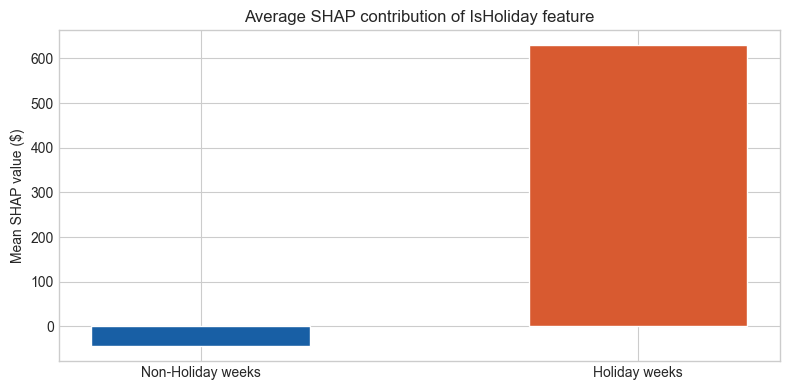

In [9]:
# Cell 8 — Holiday impact analysis via SHAP
shap_df = pd.DataFrame(shap_values, columns=FEATURES)
shap_df['IsHoliday_actual'] = sample_df['IsHoliday'].values

holiday_shap    = shap_df[shap_df['IsHoliday_actual'] == 1]['IsHoliday'].mean()
nonholiday_shap = shap_df[shap_df['IsHoliday_actual'] == 0]['IsHoliday'].mean()

print("SHAP — Holiday feature impact:")
print(f"  Holiday weeks avg SHAP value    : ${holiday_shap:,.0f}")
print(f"  Non-holiday weeks avg SHAP value: ${nonholiday_shap:,.0f}")
print(f"  Holiday adds on average         : ${holiday_shap - nonholiday_shap:,.0f} to weekly sales forecast")

plt.figure(figsize=(8,4))
bars = plt.bar(
    ['Non-Holiday weeks','Holiday weeks'],
    [nonholiday_shap, holiday_shap],
    color=['#185FA5','#D85A30'],
    edgecolor='white',
    width=0.5
)
plt.title('Average SHAP contribution of IsHoliday feature')
plt.ylabel('Mean SHAP value ($)')
plt.tight_layout()
plt.savefig('../docs/shap_holiday_impact.png', dpi=150, bbox_inches='tight')
plt.show()

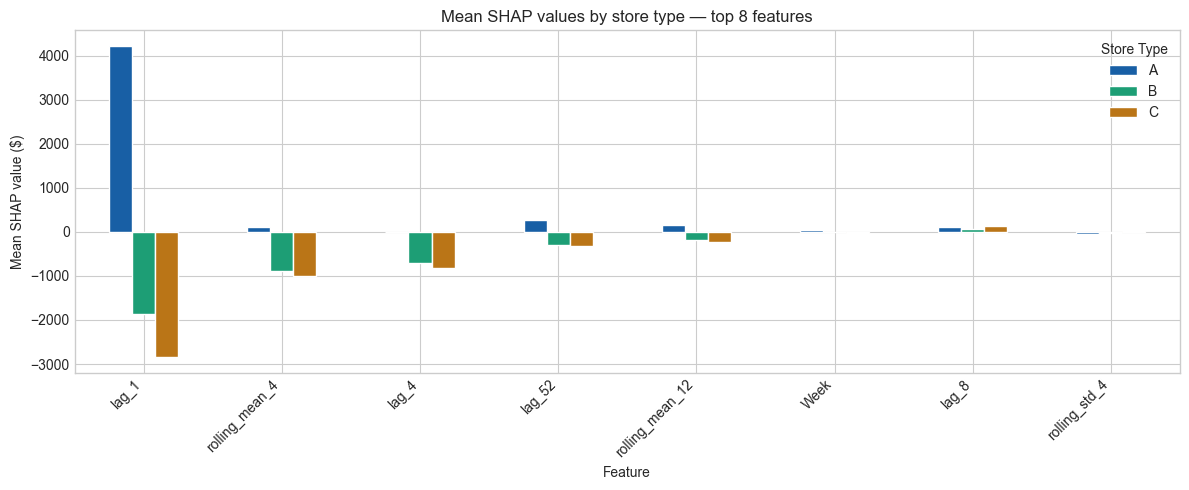

In [10]:
# Cell 9 — SHAP summary per store type
shap_df['Type'] = sample_df['Type'].values

type_shap = shap_df.groupby('Type')[FEATURES].mean().T
top_features = (
    shap_df[FEATURES].abs().mean()
    .sort_values(ascending=False)
    .head(8).index.tolist()
)

type_shap.loc[top_features].plot(
    kind='bar',
    figsize=(12,5),
    color=['#185FA5','#1D9E75','#BA7517'],
    edgecolor='white'
)
plt.title('Mean SHAP values by store type — top 8 features')
plt.xlabel('Feature')
plt.ylabel('Mean SHAP value ($)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Store Type')
plt.tight_layout()
plt.savefig('../docs/shap_by_store_type.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Cell 10 — Export SHAP summaries to JSON for ChromaDB RAG
# Top 10 global features by mean absolute SHAP
mean_shap = pd.DataFrame({
    'feature'         : FEATURES,
    'mean_abs_shap'   : np.abs(shap_values).mean(axis=0),
    'mean_shap'       : shap_values.mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

top10 = mean_shap.head(10)

# Build store-level SHAP summaries for top 5 stores
store_shap_summaries = []

for store_id in [1, 2, 3, 4, 5]:
    store_mask = sample_df['Store'] == store_id
    if store_mask.sum() == 0:
        continue

    store_shap = np.abs(shap_values[store_mask]).mean(axis=0)
    top3_idx   = store_shap.argsort()[::-1][:3]
    top3       = [(FEATURES[i], round(float(store_shap[i]), 2)) for i in top3_idx]

    store_shap_summaries.append({
        'store_id'         : int(store_id),
        'top_3_drivers'    : top3,
        'holiday_impact'   : round(float(shap_values[store_mask][:,FEATURES.index('IsHoliday')].mean()), 2),
        'lag1_impact'      : round(float(shap_values[store_mask][:,FEATURES.index('lag_1')].mean()), 2),
        'markdown_impact'  : round(float(shap_values[store_mask][:,FEATURES.index('MarkDown_Total')].mean()), 2)
    })

# Global summary
global_summary = {
    'global_top10_features': top10[['feature','mean_abs_shap']].round(4).to_dict('records'),
    'holiday_avg_shap'     : round(float(mean_shap[mean_shap['feature']=='IsHoliday']['mean_shap'].values[0]), 2),
    'top_feature'          : top10.iloc[0]['feature'],
    'store_summaries'      : store_shap_summaries
}

# Save JSON
with open('../data/processed/shap_summary.json', 'w') as f:
    json.dump(global_summary, f, indent=2)

print("SHAP summary JSON saved → data/processed/shap_summary.json")
print(f"\nTop 5 global features:")
print(top10.head(5)[['feature','mean_abs_shap']].to_string(index=False))
print(f"\nStore summaries generated for stores: {[s['store_id'] for s in store_shap_summaries]}")

SHAP summary JSON saved → data/processed/shap_summary.json

Top 5 global features:
        feature  mean_abs_shap
          lag_1   11045.587891
 rolling_mean_4    1749.633179
          lag_4    1295.709106
         lag_52    1096.849365
rolling_mean_12     577.330078

Store summaries generated for stores: [1, 2, 3, 4, 5]


In [12]:
# Cell 11 — Export SHAP data for Power BI
shap_export = pd.DataFrame(shap_values, columns=FEATURES)
shap_export['Store']      = sample_df['Store'].values
shap_export['Dept']       = sample_df['Dept'].values
shap_export['Date']       = sample_df['Date'].values
shap_export['IsHoliday']  = sample_df['IsHoliday'].values
shap_export['Type']       = sample_df['Type'].values
shap_export['Actual_Sales'] = sample_df['Weekly_Sales'].values

shap_export.to_csv('../data/processed/shap_values.csv', index=False)
shap_export.to_csv('../tableau/exports/shap_values.csv', index=False)

print(f"SHAP values exported: {shap_export.shape[0]:,} rows")
print("Saved to:")
print("  ../data/processed/shap_values.csv")
print("  ../tableau/exports/shap_values.csv")

SHAP values exported: 2,000 rows
Saved to:
  ../data/processed/shap_values.csv
  ../tableau/exports/shap_values.csv
